In [2]:
!pip install pandas numpy seaborn matplotlib scikit-learn imbalanced-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.7/252.7 MB 10.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 13.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 12.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 8.1 MB/s eta 0:00:00a 0:00:01


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings('ignore')


In [6]:
df = pd.read_csv("cleaned_merged_heart_dataset.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


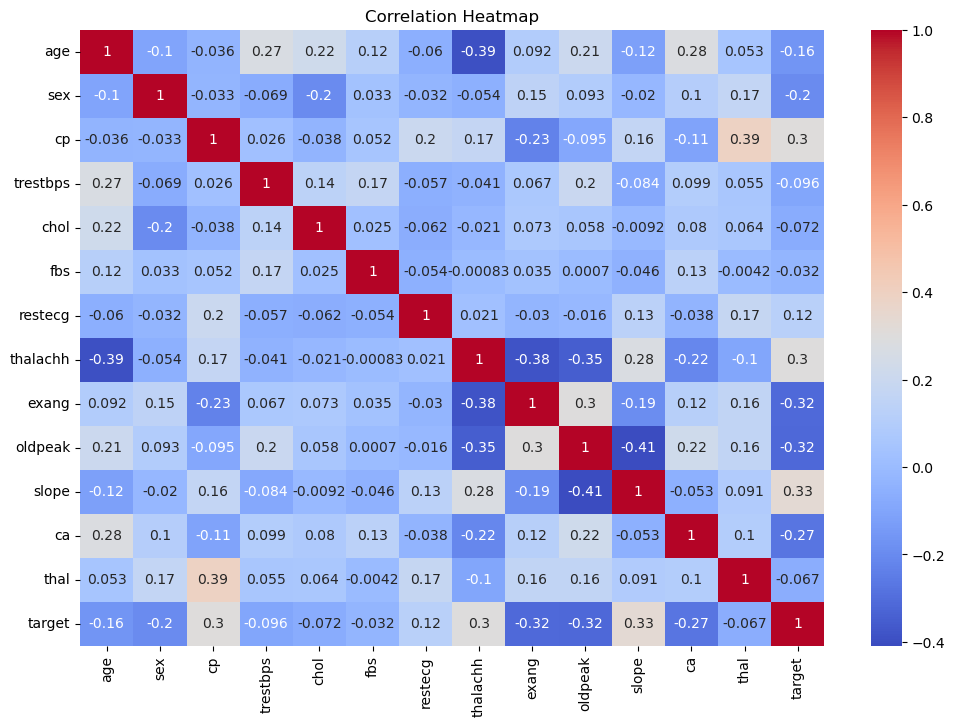

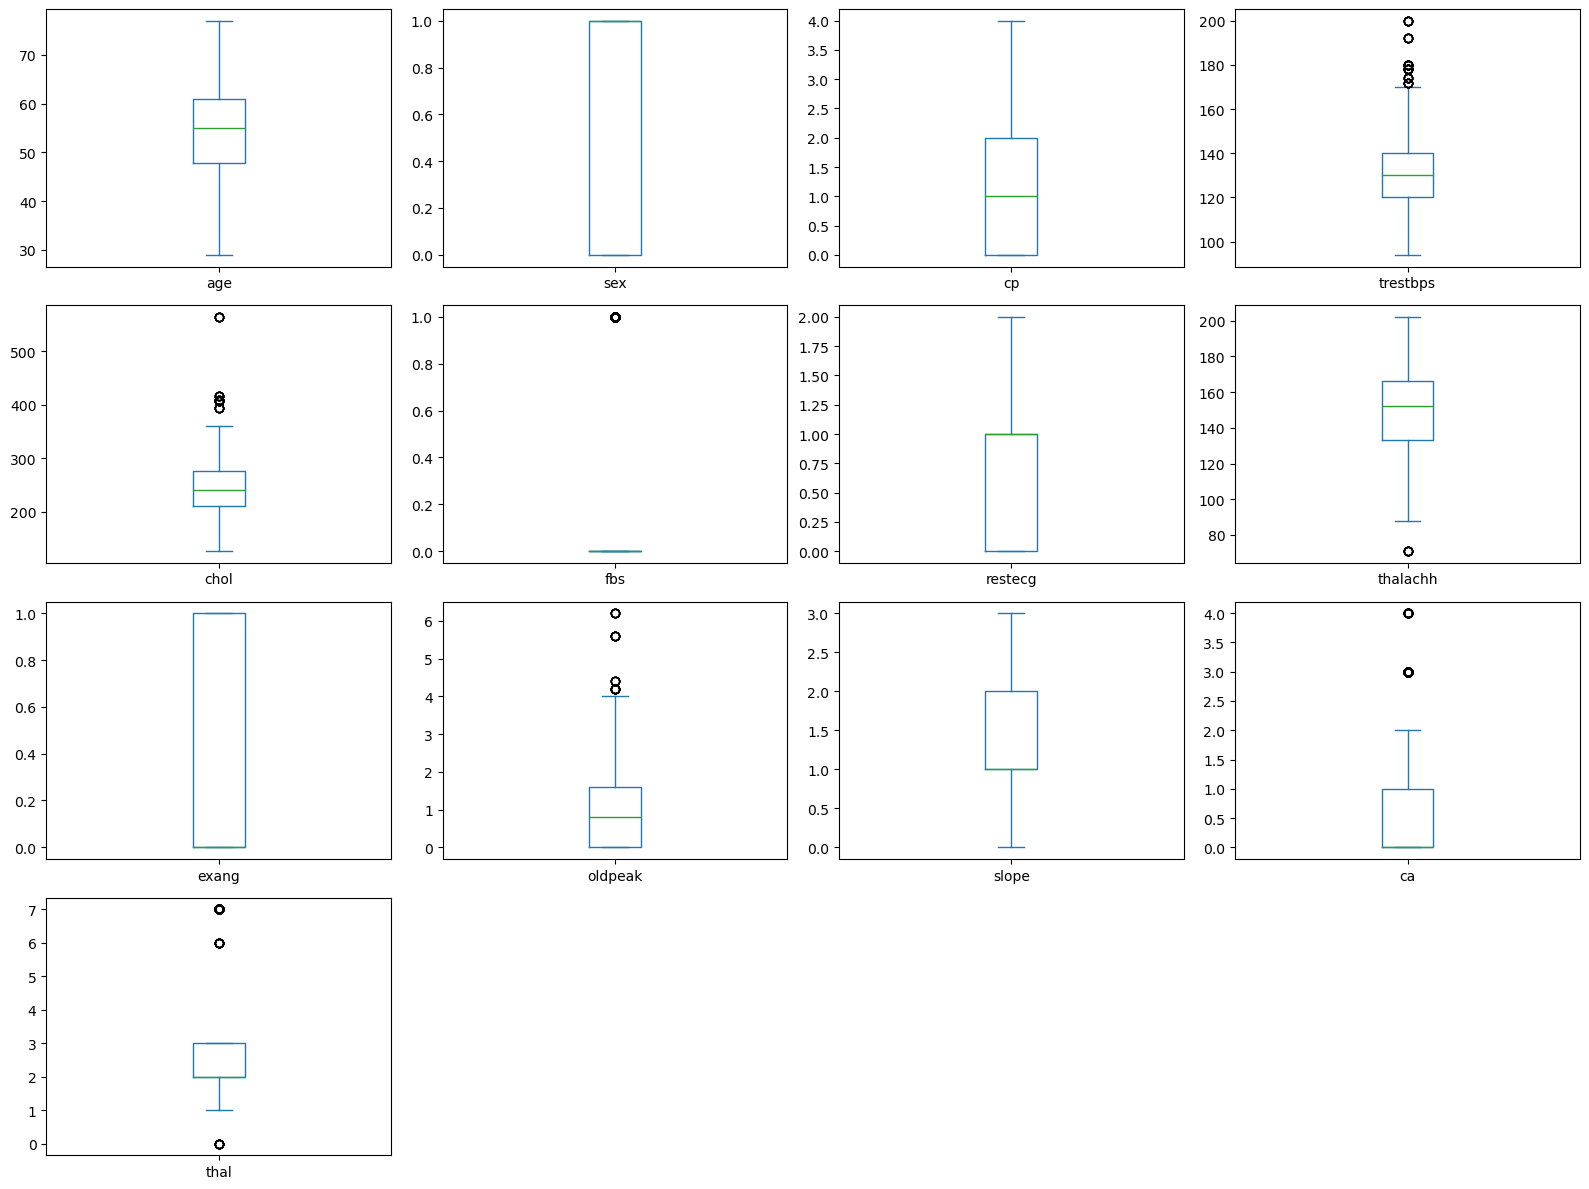

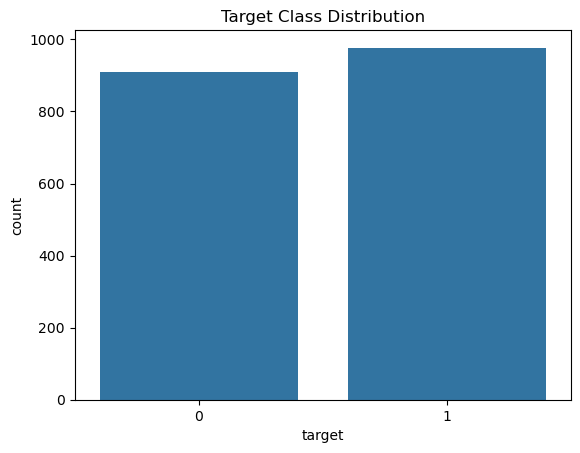

target
1    977
0    911
Name: count, dtype: int64

In [8]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Boxplots
df.drop(columns=['target']).plot(kind='box', subplots=True, layout=(4, 4), figsize=(16, 12), sharex=False)
plt.tight_layout()
plt.show()

# Class imbalance
sns.countplot(x='target', data=df)
plt.title("Target Class Distribution")
plt.show()

df['target'].value_counts()


In [10]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
df_encoded = pd.get_dummies(df, columns=categorical_cols)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']


In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)


In [33]:
input_dim = X_scaled.shape[1]
encoding_dim = 10

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu', activity_regularizer=regularizers.l1(1e-5))(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')
autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=32, shuffle=True, verbose=0)

encoder = Model(inputs=input_layer, outputs=encoded)
X_encoded = encoder.predict(X_scaled)


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 258us/step


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_resampled, test_size=0.2, random_state=42)

In [37]:
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]


In [39]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test, y_pred):.4f}")
print(f"Specificity: {tn / (tn + fp):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")


Confusion Matrix:
 [[169  22]
 [ 25 175]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.88       191
           1       0.89      0.88      0.88       200

    accuracy                           0.88       391
   macro avg       0.88      0.88      0.88       391
weighted avg       0.88      0.88      0.88       391

Accuracy: 0.8798
Precision: 0.8883
Recall (Sensitivity): 0.8750
Specificity: 0.8848
F1 Score: 0.8816


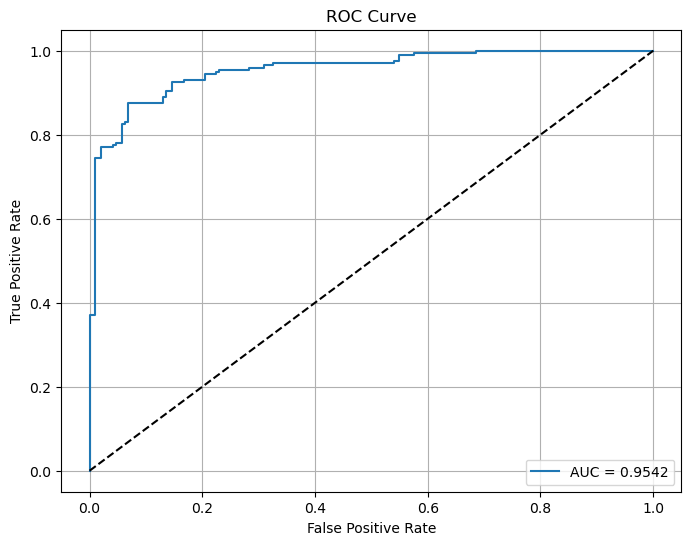

In [41]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()


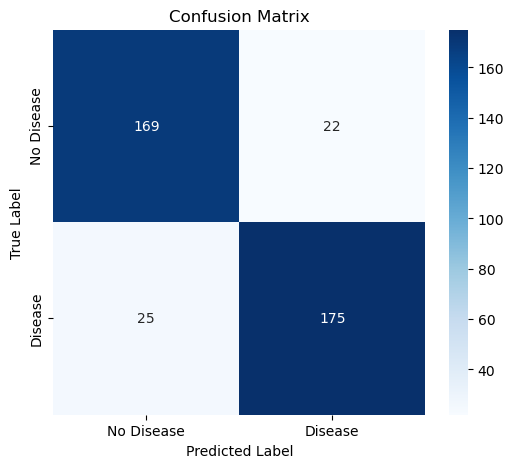

In [43]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [45]:
print(f"Total number of patients in the dataset: {df.shape[0]}")


Total number of patients in the dataset: 1888
